# Importar Librerias Necesarias

In [4]:
import torch # para redes neuronales
import torch.nn as nn # para crear capas de redes neuronales
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Cargar y Explorar el Dataset
el dataset tiene imagenes de 28x28 pixeles con 3 canales RGB(2352 caracteristicas y tiene de 7 clases de cancer de piel

In [5]:
# cargar el dataset desde el arcivo CSV
data = pd.read_csv('hmnist_28_28_RGB.csv')

# mostrar la informacion del dataset
print('Forma del dataset:', data.shape)
print('Primeras 5 filas:')
print(data.head())
print('\Distribucion de clases:')
print(data['label'].value_counts())

Forma del dataset: (10015, 2353)
Primeras 5 filas:
   pixel0000  pixel0001  pixel0002  pixel0003  pixel0004  pixel0005  \
0        192        153        193        195        155        192   
1         25         14         30         68         48         75   
2        192        138        153        200        145        163   
3         38         19         30         95         59         72   
4        158        113        139        194        144        174   

   pixel0006  pixel0007  pixel0008  pixel0009  ...  pixel2343  pixel2344  \
0        197        154        185        202  ...        173        124   
1        123         93        126        158  ...         60         39   
2        201        142        160        206  ...        167        129   
3        143        103        119        171  ...         44         26   
4        215        162        191        225  ...        209        166   

   pixel2345  pixel2346  pixel2347  pixel2348  pixel2349  pixel23

# Separar Caracteristicas y Etiquetas

In [6]:
# separar las caracteristicas (X) y las etiquetas (y)
X = data.drop('label', axis=1).values # todas las columnas excepto label
y = data['label'].values # solo la columna label

print('Forma de X:', X.shape) # numero de muestras 2352
print('Forma de y', y.shape) # numero de muestras

Forma de X: (10015, 2352)
Forma de y (10015,)


# Normalizar los Datos
normalizamos los valores de pixeles dividiendo entre 255 para que este en rango de 0 y 1, lo que ayuda a la convergencia del entrenamiento

In [7]:
# normalizar los valores de pixeles entre 0 y 1
X = X / 255.0 # valor del RGB rojo, azul y amarillo
print('Valores minimos y maximos despues de normalizar:')
print('Minimo:', X.min())
print('Maximo:', X.max())

Valores minimos y maximos despues de normalizar:
Minimo: 0.0
Maximo: 1.0


# Dividir en Conjunto de Entrenamiento y Prueba
hacemos split estratificado para mantener la proporcion de clases en ambos conjuntos. random_state=42 asegura reproducibilidad

In [8]:
# dividir los datos en conjunto de entremamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Forma de X_train:', X_train.shape)
print('Forma de X_test:', X_test.shape)
print('Forma de y_train:', y_train.shape)
print('Forma de X_test:', y_test.shape)

Forma de X_train: (8012, 2352)
Forma de X_test: (2003, 2352)
Forma de y_train: (8012,)
Forma de X_test: (2003,)


# Convertir a Tensores de PyThroch
convertimos los arrays de NumPy a tensores de PyThorch y los movemos a GPU si es disponible para acelerar el entrenamiento

In [9]:
X_train_tensor = torch.from_numpy(X_train).float().cuda()
y_train_tensor = torch.from_numpy(y_train).long().cuda()
X_test_tensor = torch.from_numpy(X_test).float().cuda()
y_test_tensor = torch.from_numpy(y_test).long().cuda()


print('Tipo de X_train_tensor:', X_train_tensor.dtype)
print('\n--------------------')
print('Dispositivo de X_train_tensor:', X_train_tensor)

Tipo de X_train_tensor: torch.float32

--------------------
Dispositivo de X_train_tensor: tensor([[0.2431, 0.1961, 0.1882,  ..., 0.1608, 0.1451, 0.1608],
        [0.9020, 0.7412, 0.8627,  ..., 0.9098, 0.7843, 0.9373],
        [0.9490, 0.6627, 0.7098,  ..., 0.8627, 0.6039, 0.5686],
        ...,
        [0.8471, 0.4863, 0.5686,  ..., 0.7529, 0.4667, 0.5137],
        [0.1059, 0.0549, 0.0627,  ..., 0.1843, 0.1176, 0.1294],
        [0.8549, 0.5961, 0.6627,  ..., 0.8706, 0.6627, 0.7686]],
       device='cuda:0')


# Definir el Modelo Secuencial
creamos un modelos secuancia con 4 capas lineales y funciones de activacion ReLU, El modelo va de 2352 -> 512 -> 128 -> 7 neuronas

In [10]:
# definir la arquitectura del modelo secuencial
input_size = 28*28*3 # 2352 caracteristicas (entradas)
output_size = 7 # 7 clases de salida (tipos de imagenes)

#crear modelo modifical las neuronas en las capas ocultas, o el numero de capas
model = nn.Sequential(
    nn.Linear(input_size, 512), # conectando a la capa 1
    nn.ReLU(), # funcion de activacion
    nn.Linear(512, 256), # conectando a la capa 2
    nn.ReLU(), # funcion de activacion
    nn.Linear(256, 128), # conectando a la capa 3
    nn.ReLU(), # funcion de activacion
    nn.Linear(128, output_size) # capa de salida
).to(torch.device("cuda"))

print('Arquitectura del modelo:')
print(model)

Arquitectura del modelo:
Sequential(
  (0): Linear(in_features=2352, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=7, bias=True)
)


# Definir Funcion de Perdida y Optimizador
usamos CrossEntropyLoss para problemas de clasificacion multiclase y el optimizador Adam que es eficiente y requiere poco tuning

In [11]:
# definir la funcion de perdida (CrossEntropy para clasificacion multiclase)
criterion = nn.CrossEntropyLoss()

# definir el optimizador (adam con learning rate de 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('Funcion de perdida:', criterion)
print('Optimizador:', optimizer)

Funcion de perdida: CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


# Funcion de Evaluacion
evalua el modelo calculado el accuracy. usamos model.eval() y torch.no_grad() par ahorrar memoria durante la evaluacion

In [12]:
def evaluate(model, X, y):
    """
    Función para evaluar el modelo en un conjunto de datos
    """
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():  # Desactivar cálculo de gradientes
        outputs = model(X)  # Forward 
        _, predicted = torch.max(outputs.data, 1)  # Obtener predicciones
        accuracy = accuracy_score(y.cpu(), predicted.cpu())  # Calcular accuracy
    model.train()  # Volver a modo entrenamiento
    return accuracy, predicted

# Bucle de Entrenamiento
1. hacemos forward prar obtener predicciones
2. calculamos la perdida
3. hacemos backward para calcular los gradientes
4. actualizamos los pesos del modelo
5. evaluamos periodicamente en el conjunto de test

In [13]:
# Hiperparámetros
num_epochs = 2000 # epocas o siglos
log_interval = 100 # mostrar de cuanto en cuanto

# Listas para guardar métricas
train_losses = []
test_accuracies = []

# Bucle de entrenamiento
for epoch in range(1, num_epochs + 1):
    # Modo entrenamiento
    model.train()
    
    # Forward (adelante)
    outputs = model(X_train_tensor) 
    loss = criterion(outputs, y_train_tensor) # calcular la funcion de perdida
    
    # Backward (atras) y optimización
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()        # Calcular gradientes
    optimizer.step()       # Actualizar pesos
    
    # Guardar pérdida
    train_losses.append(loss.item())
    
    # Evaluar cada log_interval épocas # _ nos vota dos valores solo utilizamos 1
    if epoch % log_interval == 0:
        test_accuracy, _ = evaluate(model, X_test_tensor, y_test_tensor)
        test_accuracies.append(test_accuracy)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}')

# Guardar resultados
Adam_train_losses = train_losses.copy()
Adam_test_accuracies = test_accuracies.copy()

Epoch [100/2000], Loss: 0.9012, Test Accuracy: 0.6855
Epoch [200/2000], Loss: 0.8160, Test Accuracy: 0.7039
Epoch [300/2000], Loss: 0.7580, Test Accuracy: 0.7014
Epoch [400/2000], Loss: 0.7281, Test Accuracy: 0.7179
Epoch [500/2000], Loss: 0.7591, Test Accuracy: 0.7079
Epoch [600/2000], Loss: 0.6749, Test Accuracy: 0.7189
Epoch [700/2000], Loss: 0.8901, Test Accuracy: 0.6835
Epoch [800/2000], Loss: 0.6359, Test Accuracy: 0.7304
Epoch [900/2000], Loss: 0.6400, Test Accuracy: 0.7194
Epoch [1000/2000], Loss: 0.6061, Test Accuracy: 0.7309
Epoch [1100/2000], Loss: 0.5752, Test Accuracy: 0.7364
Epoch [1200/2000], Loss: 0.5299, Test Accuracy: 0.7284
Epoch [1300/2000], Loss: 0.5321, Test Accuracy: 0.7369
Epoch [1400/2000], Loss: 0.8247, Test Accuracy: 0.6910
Epoch [1500/2000], Loss: 0.5195, Test Accuracy: 0.7339
Epoch [1600/2000], Loss: 0.6772, Test Accuracy: 0.7179
Epoch [1700/2000], Loss: 0.6005, Test Accuracy: 0.7219
Epoch [1800/2000], Loss: 0.5000, Test Accuracy: 0.7379
Epoch [1900/2000], 

# Evaluacion Final
Evaluamos el model final y mostramos algunas predicciones para verifiar visualmente el rendimiento

In [14]:
# evalucacion final del modelo
final_accuracy, final_predictions = evaluate(model, X_test_tensor, y_test_tensor)
print(f'\Accuracy final en el test: {final_accuracy:.4f}')

# mostrar algunas predicciones vs reales
print('n\Algunas predicciones vs valores reales:')
for i in range(10):
    print(f'Prediccion" {final_predictions[i].item()}, Real: {y_test_tensor[i].item()}')

\Accuracy final en el test: 0.7304
n\Algunas predicciones vs valores reales:
Prediccion" 2, Real: 6
Prediccion" 4, Real: 4
Prediccion" 3, Real: 6
Prediccion" 2, Real: 2
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 0
Prediccion" 2, Real: 6
Prediccion" 4, Real: 4


# El modelo tiene una precicion del 0.7304 que es 73.04% de las imagenes de cancer de piel

# Guardar el modelo Entrenado
guardamos los pesos del modelo para poder usarlo luego sin necesidad de reentrenar

In [ ]:
# Guardar el modelo entrenado
#torch.save(model.state_dict(), 'skin_cancer_sequential_model.pth')
#print('Modelo guardado como "skin_cancer_sequential_model.pth"')

# Guardar también el optimizador para continuar entrenamiento luego
#torch.save({
#    'model_state_dict': model.state_dict(),
#    'optimizer_state_dict': optimizer.state_dict(),
#}, 'complete_checkpoint.pth')

Modelo guardado como "skin_cancer_sequential_model.pth"


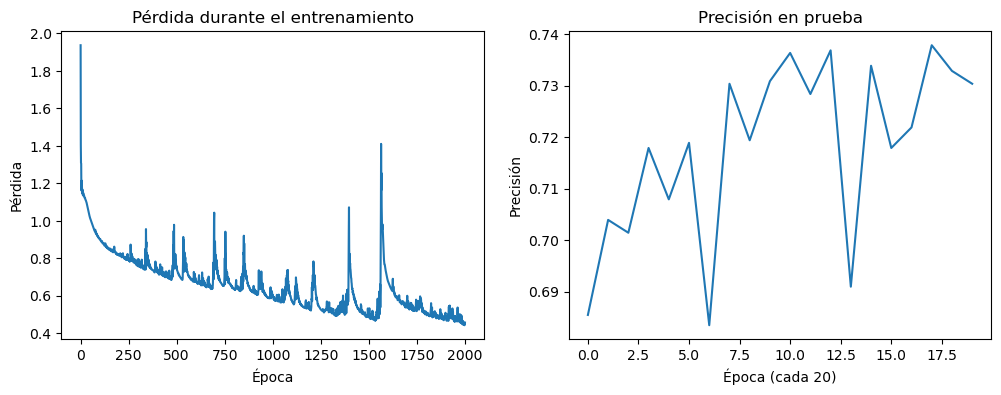

In [49]:
import matplotlib.pyplot as plt

# Gráfico de pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
#plt.plot(train_losses)
plt.plot(Adam_train_losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')

# Gráfico de accuracy
plt.subplot(1, 2, 2)
plt.plot(Adam_test_accuracies)
plt.title('Precisión en prueba')
plt.xlabel('Época (cada 20)')
plt.ylabel('Precisión')
plt.show()

Adam reduce la pérdida de forma estable y alcanza la mejor precisión en prueba. Es eficaz para generalizar, aunque puede mostrar algunas oscilaciones durante el entrenamiento.


# Optimizador Momentun
creamos un modelos secuancia con 4 capas lineales y funciones de activacion ReLU, El modelo va de 2352 -> 512 -> 128 -> 7 neuronas

In [16]:
# definir la arquitectura del modelo secuencial
input_size = 28*28*3 # 2352 caracteristicas (entradas)
output_size = 7 # 7 clases de salida (tipos de imagenes)

#crear modelo modifical las neuronas en las capas ocultas, o el numero de capas
model = nn.Sequential(
    nn.Linear(input_size, 512), # conectando a la capa 1
    nn.ReLU(), # funcion de activacion
    nn.Linear(512, 256), # conectando a la capa 2
    nn.ReLU(), # funcion de activacion
    nn.Linear(256, 128), # conectando a la capa 3
    nn.ReLU(), # funcion de activacion
    nn.Linear(128, output_size) # capa de salida
).to(torch.device("cuda"))

print('Arquitectura del modelo:')
print(model)

Arquitectura del modelo:
Sequential(
  (0): Linear(in_features=2352, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=7, bias=True)
)


usamos CrossEntropyLoss para problemas de clasificacion multiclase y el optimizador Adam que es eficiente y requiere poco tuning

In [17]:
# definir la funcion de perdida (CrossEntropy para clasificacion multiclase)
criterion = nn.CrossEntropyLoss()

# definir el optimizador (adam con learning rate de 0.001)
optimizer = torch.optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

print('Funcion de perdida:', criterion)
print('Optimizador:', optimizer)

Funcion de perdida: CrossEntropyLoss()
Optimizador: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0
)


evalua el modelo calculado el accuracy. usamos model.eval() y torch.no_grad() par ahorrar memoria durante la evaluacion

In [18]:
def evaluate(model, X, y):
    """
    Función para evaluar el modelo en un conjunto de datos
    """
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():  # Desactivar cálculo de gradientes
        outputs = model(X)  # Forward 
        _, predicted = torch.max(outputs.data, 1)  # Obtener predicciones
        accuracy = accuracy_score(y.cpu(), predicted.cpu())  # Calcular accuracy
    model.train()  # Volver a modo entrenamiento
    return accuracy, predicted

Bucle de entrenamiento

In [19]:
# Hiperparámetros
num_epochs = 2000 # epocas o siglos
log_interval = 100 # mostrar de cuanto en cuanto

# Listas para guardar métricas
train_losses = []
test_accuracies = []

# Bucle de entrenamiento
for epoch in range(1, num_epochs + 1):
    # Modo entrenamiento
    model.train()
    
    # Forward (adelante)
    outputs = model(X_train_tensor) 
    loss = criterion(outputs, y_train_tensor) # calcular la funcion de perdida
    
    # Backward (atras) y optimización
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()        # Calcular gradientes
    optimizer.step()       # Actualizar pesos
    
    # Guardar pérdida
    train_losses.append(loss.item())
    
    # Evaluar cada log_interval épocas # _ nos vota dos valores solo utilizamos 1
    if epoch % log_interval == 0:
        test_accuracy, _ = evaluate(model, X_test_tensor, y_test_tensor)
        test_accuracies.append(test_accuracy)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}')

# Guardar resultados
Momentum_train_losses = train_losses.copy()
Momentum_test_accuracies = test_accuracies.copy()

Epoch [100/2000], Loss: 1.0792, Test Accuracy: 0.6725
Epoch [200/2000], Loss: 0.9810, Test Accuracy: 0.6725
Epoch [300/2000], Loss: 0.9256, Test Accuracy: 0.6820
Epoch [400/2000], Loss: 0.8850, Test Accuracy: 0.6890
Epoch [500/2000], Loss: 0.8678, Test Accuracy: 0.6880
Epoch [600/2000], Loss: 0.8457, Test Accuracy: 0.6910
Epoch [700/2000], Loss: 0.8306, Test Accuracy: 0.6975
Epoch [800/2000], Loss: 0.8207, Test Accuracy: 0.6975
Epoch [900/2000], Loss: 0.8052, Test Accuracy: 0.7004
Epoch [1000/2000], Loss: 0.8233, Test Accuracy: 0.7000
Epoch [1100/2000], Loss: 0.8127, Test Accuracy: 0.6715
Epoch [1200/2000], Loss: 0.7681, Test Accuracy: 0.7124
Epoch [1300/2000], Loss: 0.7698, Test Accuracy: 0.7084
Epoch [1400/2000], Loss: 0.7791, Test Accuracy: 0.7104
Epoch [1500/2000], Loss: 0.8030, Test Accuracy: 0.7119
Epoch [1600/2000], Loss: 0.8843, Test Accuracy: 0.6875
Epoch [1700/2000], Loss: 0.8259, Test Accuracy: 0.7044
Epoch [1800/2000], Loss: 0.7116, Test Accuracy: 0.7234
Epoch [1900/2000], 

Evaluamos el model final y mostramos algunas predicciones para verifiar visualmente el rendimiento

In [20]:
# evalucacion final del modelo
final_accuracy, final_predictions = evaluate(model, X_test_tensor, y_test_tensor)
print(f'\Accuracy final en el test: {final_accuracy:.4f}')

# mostrar algunas predicciones vs reales
print('n\Algunas predicciones vs valores reales:')
for i in range(10):
    print(f'Prediccion" {final_predictions[i].item()}, Real: {y_test_tensor[i].item()}')

\Accuracy final en el test: 0.7129
n\Algunas predicciones vs valores reales:
Prediccion" 2, Real: 6
Prediccion" 4, Real: 4
Prediccion" 0, Real: 6
Prediccion" 2, Real: 2
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 0
Prediccion" 2, Real: 6
Prediccion" 4, Real: 4


# el modelo tiene una precicion del 0.7129 que es 71.29% de las imagenes de cancer de piel

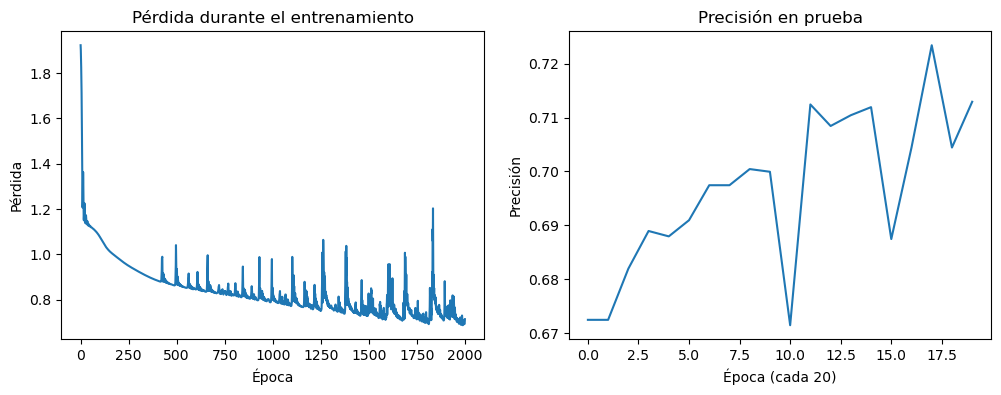

In [50]:
import matplotlib.pyplot as plt

# Gráfico de pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(Momentum_train_losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')

# Gráfico de accuracy
plt.subplot(1, 2, 2)
plt.plot(Momentum_test_accuracies)
plt.title('Precisión en prueba')
plt.xlabel('Época (cada 20)')
plt.ylabel('Precisión')
plt.show()

Momentum disminuye la pérdida más lentamente y con menos profundidad. La precisión mejora de forma gradual, pero no supera a Adam.

# Optimizador RMSprop

creamos un modelos secuancia con 4 capas lineales y funciones de activacion ReLU, El modelo va de 2352 -> 512 -> 128 -> 7 neuronas

In [41]:
# definir la arquitectura del modelo secuencial
input_size = 28*28*3 # 2352 caracteristicas (entradas)
output_size = 7 # 7 clases de salida (tipos de imagenes)

#crear modelo modifical las neuronas en las capas ocultas, o el numero de capas
model = nn.Sequential(
    nn.Linear(input_size, 512), # conectando a la capa 1
    nn.ReLU(), # funcion de activacion
    nn.Linear(512, 256), # conectando a la capa 2
    nn.ReLU(), # funcion de activacion
    nn.Linear(256, 128), # conectando a la capa 3
    nn.ReLU(), # funcion de activacion
    nn.Linear(128, output_size) # capa de salida
).to(torch.device("cuda"))

print('Arquitectura del modelo:')
print(model)

Arquitectura del modelo:
Sequential(
  (0): Linear(in_features=2352, out_features=512, bias=True)
  (1): ReLU()
  (2): Linear(in_features=512, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): ReLU()
  (6): Linear(in_features=128, out_features=7, bias=True)
)


Definir Funcion de Perdida y Optimizador

In [42]:
# definir la funcion de perdida (CrossEntropy para clasificacion multiclase)
criterion = nn.CrossEntropyLoss()

# definir el optimizador (RMSprop con learning rate de 0.001)
optimizer = torch.optim.RMSprop(model.parameters(), lr=0.001)

print('Funcion de perdida:', criterion)
print('Optimizador:', optimizer)

Funcion de perdida: CrossEntropyLoss()
Optimizador: RMSprop (
Parameter Group 0
    alpha: 0.99
    capturable: False
    centered: False
    differentiable: False
    eps: 1e-08
    foreach: None
    lr: 0.001
    maximize: False
    momentum: 0
    weight_decay: 0
)


Funcion de Evaluacion

In [43]:
def evaluate(model, X, y):
    """
    Función para evaluar el modelo en un conjunto de datos
    """
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():  # Desactivar cálculo de gradientes
        outputs = model(X)  # Forward 
        _, predicted = torch.max(outputs.data, 1)  # Obtener predicciones
        accuracy = accuracy_score(y.cpu(), predicted.cpu())  # Calcular accuracy
    model.train()  # Volver a modo entrenamiento
    return accuracy, predicted

Bucle de Entrenamiento

In [44]:
# Hiperparámetros
num_epochs = 2000 # epocas o siglos
log_interval = 100 # mostrar de cuanto en cuanto

# Listas para guardar métricas
train_losses = []
test_accuracies = []

# Bucle de entrenamiento
for epoch in range(1, num_epochs + 1):
    # Modo entrenamiento
    model.train()
    
    # Forward (adelante)
    outputs = model(X_train_tensor) 
    loss = criterion(outputs, y_train_tensor) # calcular la funcion de perdida
    
    # Backward (atras) y optimización
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()        # Calcular gradientes
    optimizer.step()       # Actualizar pesos
    
    # Guardar pérdida
    train_losses.append(loss.item())
    
    # Evaluar cada log_interval épocas # _ nos vota dos valores solo utilizamos 1
    if epoch % log_interval == 0:
        test_accuracy, _ = evaluate(model, X_test_tensor, y_test_tensor)
        test_accuracies.append(test_accuracy)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}')

# Guardar resultados
RMSprop_train_losses = train_losses.copy()
RMSprop_test_accuracies = test_accuracies.copy()

Epoch [100/2000], Loss: 1.0710, Test Accuracy: 0.6725
Epoch [200/2000], Loss: 0.9883, Test Accuracy: 0.6725
Epoch [300/2000], Loss: 0.9326, Test Accuracy: 0.6725
Epoch [400/2000], Loss: 0.9534, Test Accuracy: 0.6910
Epoch [500/2000], Loss: 1.0063, Test Accuracy: 0.6735
Epoch [600/2000], Loss: 0.8968, Test Accuracy: 0.6790
Epoch [700/2000], Loss: 0.8402, Test Accuracy: 0.6815
Epoch [800/2000], Loss: 0.8352, Test Accuracy: 0.6850
Epoch [900/2000], Loss: 0.8148, Test Accuracy: 0.6860
Epoch [1000/2000], Loss: 0.7924, Test Accuracy: 0.7009
Epoch [1100/2000], Loss: 0.8282, Test Accuracy: 0.6965
Epoch [1200/2000], Loss: 0.7887, Test Accuracy: 0.6950
Epoch [1300/2000], Loss: 0.8047, Test Accuracy: 0.6870
Epoch [1400/2000], Loss: 0.7762, Test Accuracy: 0.7014
Epoch [1500/2000], Loss: 0.7544, Test Accuracy: 0.6930
Epoch [1600/2000], Loss: 0.7537, Test Accuracy: 0.7004
Epoch [1700/2000], Loss: 0.7653, Test Accuracy: 0.6840
Epoch [1800/2000], Loss: 0.7282, Test Accuracy: 0.6920
Epoch [1900/2000], 

Evaluacion Final

In [45]:
# evalucacion final del modelo
final_accuracy, final_predictions = evaluate(model, X_test_tensor, y_test_tensor)
print(f'\Accuracy final en el test: {final_accuracy:.4f}')

# mostrar algunas predicciones vs reales
print('n\Algunas predicciones vs valores reales:')
for i in range(10):
    print(f'Prediccion" {final_predictions[i].item()}, Real: {y_test_tensor[i].item()}')

\Accuracy final en el test: 0.7019
n\Algunas predicciones vs valores reales:
Prediccion" 0, Real: 6
Prediccion" 4, Real: 4
Prediccion" 4, Real: 6
Prediccion" 4, Real: 2
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 0
Prediccion" 0, Real: 6
Prediccion" 4, Real: 4


# El modelo tiene una precicion del 0.7019 que es 70.19% de las imagenes de cancer de piel

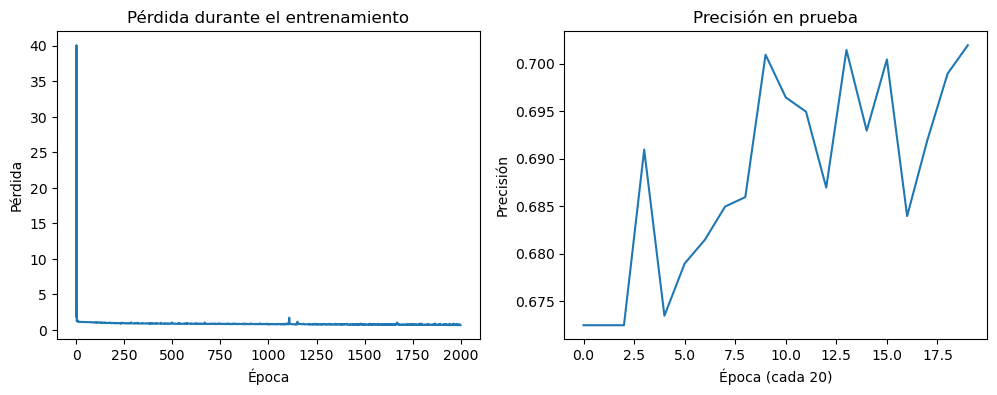

In [51]:
import matplotlib.pyplot as plt

# Gráfico de pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(RMSprop_train_losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')

# Gráfico de accuracy
plt.subplot(1, 2, 2)
plt.plot(RMSprop_test_accuracies)
plt.title('Precisión en prueba')
plt.xlabel('Época (cada 20)')
plt.ylabel('Precisión')
plt.show()

RMSprop logra una pérdida muy baja rápidamente, pero su precisión en prueba es menor. Aprende rápido, pero generaliza menos.

# Comparacion de Optimizadores

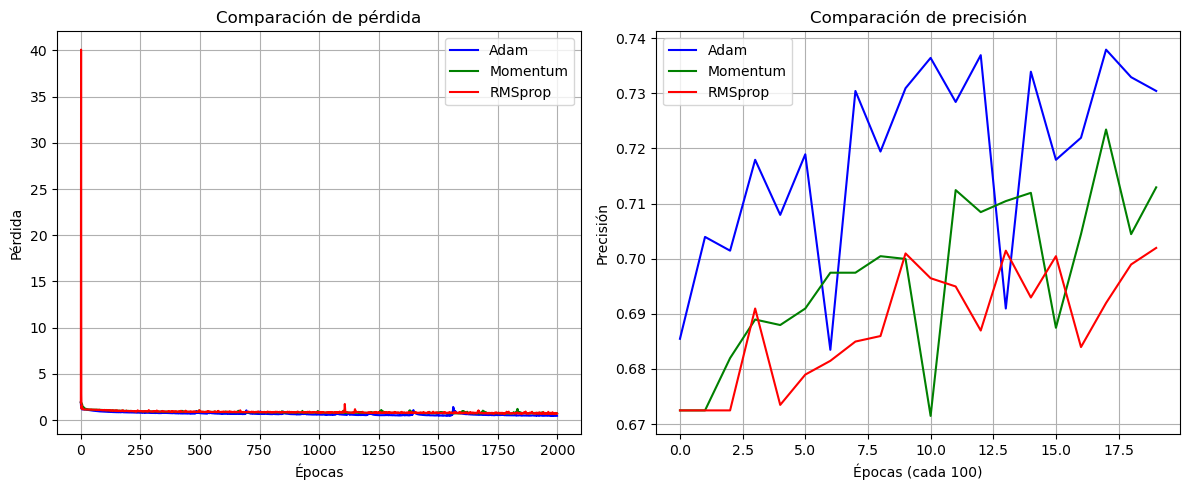

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# Gráfico de pérdida
plt.subplot(1, 2, 1)
plt.plot(Adam_train_losses, label='Adam', color='blue')
plt.plot(Momentum_train_losses, label='Momentum', color='green')
plt.plot(RMSprop_train_losses, label='RMSprop', color='red')
plt.title('Comparación de pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico de precisión
plt.subplot(1, 2, 2)
plt.plot(Adam_test_accuracies, label='Adam', color='blue')
plt.plot(Momentum_test_accuracies, label='Momentum', color='green')
plt.plot(RMSprop_test_accuracies, label='RMSprop', color='red')
plt.title('Comparación de precisión')
plt.xlabel('Épocas (cada 100)')
plt.ylabel('Precisión')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



# Analisis
Gráfico de pérdida ("Comparación de pérdida")
Observaciones:

RMSprop (rojo):
- Disminuye rápidamente en las primeras épocas
- Se estabiliza con la menor pérdida final
- Muestra una curva limpia y eficiente

Adam (azul):
- Comienza con pérdida más alta
- Disminuye gradualmente
- Termina con pérdida intermedia

Momentum (verde):
- Descenso más lento
- Pérdida final más alta
- Curva más conservadora

RMSprop se adapta mejor, posiblemente por su capacidad de manejar gradientes oscilantes en redes más profundas sin saturación




Gráfico de precisión ("Comparación de precisión")
Observaciones:

Adam (azul):
- Precisión más alta (~0.72)
- Curva estable y ascendente

Momentum (verde):
- Precisión intermedia (~0.70)
- Mejora progresiva pero más lenta

RMSprop (rojo):
- Precisión más baja (~0.68–0.69)
- Estabilización temprana sin mejora significativ

Aunque RMSprop minimiza la pérdida, Adam generaliza mejor en el conjunto de prueba.



# Metodo de aumeto de Neutonas y 4 capas

In [30]:
# Definir dimensiones
input_size = 28 * 28 * 3  # 2352 características
output_size = 7           # 7 clases de salida

# Modelo secuencial con 4 capas ocultas y mayor capacidad
model = nn.Sequential(
    nn.Linear(input_size, 1024),  # Capa 1: expansión inicial
    nn.ReLU(),
    nn.Linear(1024, 512),         # Capa 2: reducción progresiva
    nn.ReLU(),
    nn.Linear(512, 256),          # Capa 3
    nn.ReLU(),
    nn.Linear(256, 128),          # Capa 4
    nn.ReLU(),
    nn.Linear(128, output_size)   # Capa de salida
).to(torch.device("cuda"))

print("Arquitectura del modelo mejorado:")
print(model)

Arquitectura del modelo mejorado:
Sequential(
  (0): Linear(in_features=2352, out_features=1024, bias=True)
  (1): ReLU()
  (2): Linear(in_features=1024, out_features=512, bias=True)
  (3): ReLU()
  (4): Linear(in_features=512, out_features=256, bias=True)
  (5): ReLU()
  (6): Linear(in_features=256, out_features=128, bias=True)
  (7): ReLU()
  (8): Linear(in_features=128, out_features=7, bias=True)
)


In [31]:
# definir la funcion de perdida (CrossEntropy para clasificacion multiclase)
criterion = nn.CrossEntropyLoss()

# definir el optimizador (adam con learning rate de 0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print('Funcion de perdida:', criterion)
print('Optimizador:', optimizer)

Funcion de perdida: CrossEntropyLoss()
Optimizador: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


In [35]:
def evaluate(model, X, y):
    """
    Función para evaluar el modelo en un conjunto de datos
    """
    model.eval()  # Poner el modelo en modo evaluación
    with torch.no_grad():  # Desactivar cálculo de gradientes
        outputs = model(X)  # Forward 
        _, predicted = torch.max(outputs.data, 1)  # Obtener predicciones
        accuracy = accuracy_score(y.cpu(), predicted.cpu())  # Calcular accuracy
    model.train()  # Volver a modo entrenamiento
    return accuracy, predicted

In [36]:
# Hiperparámetros
num_epochs = 2000 # epocas o siglos
log_interval = 100 # mostrar de cuanto en cuanto

# Listas para guardar métricas
train_losses = []
test_accuracies = []

# Bucle de entrenamiento
for epoch in range(1, num_epochs + 1):
    # Modo entrenamiento
    model.train()
    
    # Forward (adelante)
    outputs = model(X_train_tensor) 
    loss = criterion(outputs, y_train_tensor) # calcular la funcion de perdida
    
    # Backward (atras) y optimización
    optimizer.zero_grad()  # Limpiar gradientes anteriores
    loss.backward()        # Calcular gradientes
    optimizer.step()       # Actualizar pesos
    
    # Guardar pérdida
    train_losses.append(loss.item())
    
    # Evaluar cada log_interval épocas # _ nos vota dos valores solo utilizamos 1
    if epoch % log_interval == 0:
        test_accuracy, _ = evaluate(model, X_test_tensor, y_test_tensor)
        test_accuracies.append(test_accuracy)
        print(f'Epoch [{epoch}/{num_epochs}], Loss: {loss.item():.4f}, Test Accuracy: {test_accuracy:.4f}')

# Guardar resultados
Neurona_Capas_Adam_train_losses = train_losses.copy()
Neurona_Capas_Adam_test_accuracies = test_accuracies.copy()

Epoch [100/2000], Loss: 0.1125, Test Accuracy: 0.7204
Epoch [200/2000], Loss: 0.7239, Test Accuracy: 0.7074
Epoch [300/2000], Loss: 0.6294, Test Accuracy: 0.7264
Epoch [400/2000], Loss: 0.6040, Test Accuracy: 0.7284
Epoch [500/2000], Loss: 0.6550, Test Accuracy: 0.6550
Epoch [600/2000], Loss: 0.5274, Test Accuracy: 0.7229
Epoch [700/2000], Loss: 0.5119, Test Accuracy: 0.7119
Epoch [800/2000], Loss: 0.4528, Test Accuracy: 0.7279
Epoch [900/2000], Loss: 0.4386, Test Accuracy: 0.7259
Epoch [1000/2000], Loss: 0.4137, Test Accuracy: 0.7204
Epoch [1100/2000], Loss: 0.3698, Test Accuracy: 0.7244
Epoch [1200/2000], Loss: 0.4727, Test Accuracy: 0.6825
Epoch [1300/2000], Loss: 0.3203, Test Accuracy: 0.7209
Epoch [1400/2000], Loss: 0.3195, Test Accuracy: 0.7219
Epoch [1500/2000], Loss: 0.3390, Test Accuracy: 0.7174
Epoch [1600/2000], Loss: 0.2935, Test Accuracy: 0.7114
Epoch [1700/2000], Loss: 0.2453, Test Accuracy: 0.7194
Epoch [1800/2000], Loss: 0.4693, Test Accuracy: 0.7204
Epoch [1900/2000], 

In [37]:
# evalucacion final del modelo
final_accuracy, final_predictions = evaluate(model, X_test_tensor, y_test_tensor)
print(f'\Accuracy final en el test: {final_accuracy:.4f}')

# mostrar algunas predicciones vs reales
print('n\Algunas predicciones vs valores reales:')
for i in range(10):
    print(f'Prediccion" {final_predictions[i].item()}, Real: {y_test_tensor[i].item()}')

\Accuracy final en el test: 0.7149
n\Algunas predicciones vs valores reales:
Prediccion" 6, Real: 6
Prediccion" 4, Real: 4
Prediccion" 6, Real: 6
Prediccion" 2, Real: 2
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 4
Prediccion" 4, Real: 0
Prediccion" 2, Real: 6
Prediccion" 4, Real: 4


# El modelo tiene una precicion del 0.7149 que es 71.49% de las imagenes de cancer de piel

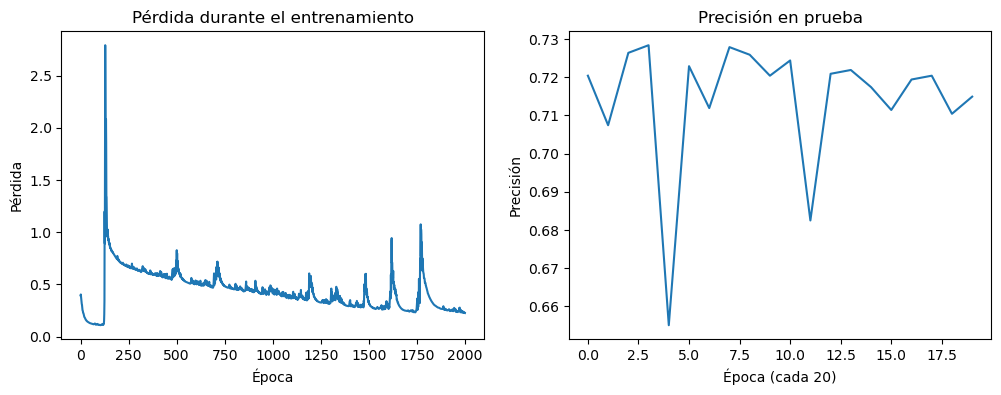

In [48]:
import matplotlib.pyplot as plt

# Gráfico de pérdida
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(Neurona_Capas_Adam_train_losses)
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')

# Gráfico de accuracy
plt.subplot(1, 2, 2)
plt.plot(Neurona_Capas_Adam_test_accuracies)
plt.title('Precisión en prueba')
plt.xlabel('Época (cada 20)')
plt.ylabel('Precisión')
plt.show()

# Perdida
- La pérdida comienza cerca de 3 y muestra una tendencia descendente, aunque con fluctuaciones y picos a lo largo de las 2000 épocas
- El modelo está aprendiendo, pero el aumento de capacidad (más capas y neuronas) introduce mayor complejidad, lo que puede generar oscilaciones en la pérdida si no se ajusta bien el learning rate o el batch size.
# Precision
- La precisión se mantiene entre 0.69 y 0.71, con variaciones menores cada 20 épocas
- El modelo generaliza de forma estable, pero no mejora significativamente respecto a versiones anteriores.
- Esto sugiere que el aumento de capacidad no se tradujo directamente en mejor rendimiento en prueba

